<a href="https://colab.research.google.com/github/sarvesh35ss/DAA2/blob/main/DAA2a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STRING MATCHING ALGORITHM COMPARISON
Text Length: 10000



,Pattern Length,Naive,KMP,Rabin-Karp
0,5,10373,10364,102
1,10,10414,10409,92
2,20,10370,10370,91
3,50,10371,10410,104



Patterns Used:
Length 5 : yxsta
Length 10 : zyppcoyhba
Length 20 : nqlhwzabuvnwrtobtsll
Length 50 : dlxzjflbgpftxuozasvbdebjrghpmdbgomtjxfsyuhqngsnbxs


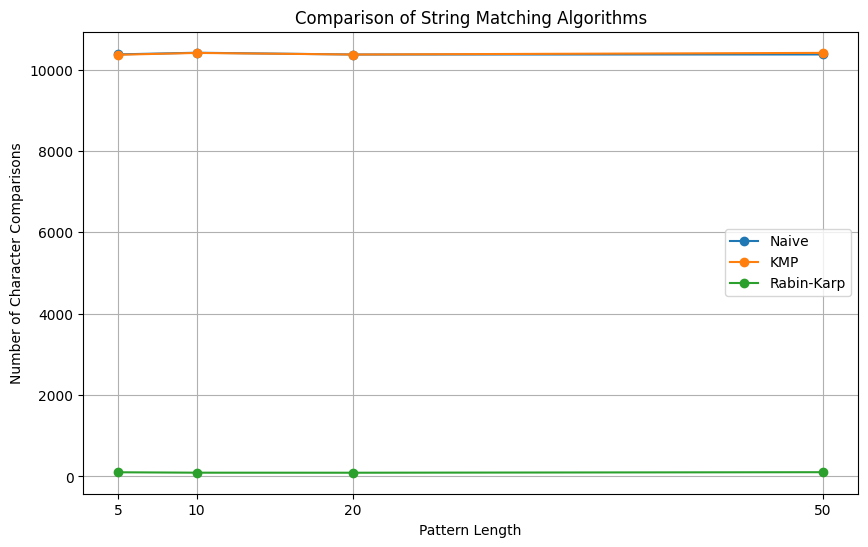

In [ ]:
import random
import string
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# STRING MATCHING ALGORITHMS
# ==========================================

# Generate text of 10,000 characters
random.seed(42)

n = 10000
text = ''.join(random.choices(string.ascii_lowercase, k=n))

pattern_lengths = [5, 10, 20, 50]


# ==========================================
# 1. NAIVE STRING MATCHING
# ==========================================

def naive_search(text, pattern):

    n = len(text)
    m = len(pattern)

    comparisons = 0
    positions = []

    for i in range(n - m + 1):

        j = 0

        while j < m:

            comparisons += 1

            if text[i + j] != pattern[j]:
                break

            j += 1

        if j == m:
            positions.append(i)

    return positions, comparisons


# ==========================================
# 2. KMP STRING MATCHING
# ==========================================

def compute_lps(pattern):

    m = len(pattern)

    lps = [0] * m

    length = 0
    i = 1

    while i < m:

        if pattern[i] == pattern[length]:

            length += 1
            lps[i] = length
            i += 1

        else:

            if length != 0:
                length = lps[length - 1]

            else:
                lps[i] = 0
                i += 1

    return lps


def kmp_search(text, pattern):

    n = len(text)
    m = len(pattern)

    lps = compute_lps(pattern)

    i = 0
    j = 0

    comparisons = 0
    positions = []

    while i < n:

        comparisons += 1

        if text[i] == pattern[j]:

            i += 1
            j += 1

            if j == m:

                positions.append(i - j)

                j = lps[j - 1]

        else:

            if j != 0:

                j = lps[j - 1]

            else:

                i += 1

    return positions, comparisons


# ==========================================
# 3. RABIN-KARP STRING MATCHING
# ==========================================

def rabin_karp_search(text, pattern):

    n = len(text)
    m = len(pattern)

    if m > n:
        return [], 0

    d = 256
    prime = 101

    pattern_hash = 0
    text_hash = 0

    h = 1

    comparisons = 0
    positions = []

    # Calculate d^(m-1)
    for _ in range(m - 1):
        h = (h * d) % prime

    # Initial hash
    for i in range(m):

        pattern_hash = (
            d * pattern_hash + ord(pattern[i])
        ) % prime

        text_hash = (
            d * text_hash + ord(text[i])
        ) % prime

    # Search
    for i in range(n - m + 1):

        if pattern_hash == text_hash:

            j = 0

            while j < m:

                comparisons += 1

                if text[i + j] != pattern[j]:
                    break

                j += 1

            if j == m:
                positions.append(i)

        # Rolling hash
        if i < n - m:

            text_hash = (
                d * (text_hash - ord(text[i]) * h)
                + ord(text[i + m])
            ) % prime

            if text_hash < 0:
                text_hash += prime

    return positions, comparisons


# ==========================================
# 4. CREATE PATTERNS
# ==========================================

patterns = {}

for length in pattern_lengths:

    patterns[length] = ''.join(
        random.choices(string.ascii_lowercase, k=length)
    )


# ==========================================
# 5. RUN ALL ALGORITHMS
# ==========================================

results = []

for length in pattern_lengths:

    pattern = patterns[length]

    # Naive
    _, naive_count = naive_search(text, pattern)

    # KMP
    _, kmp_count = kmp_search(text, pattern)

    # Rabin-Karp
    _, rk_count = rabin_karp_search(text, pattern)

    results.append({
        "Pattern Length": length,
        "Naive": naive_count,
        "KMP": kmp_count,
        "Rabin-Karp": rk_count
    })


# ==========================================
# 6. DISPLAY RESULTS
# ==========================================

df = pd.DataFrame(results)

print("==========================================")
print("STRING MATCHING ALGORITHM COMPARISON")
print("==========================================")
print("Text Length:", n)
print()

display(df)


# ==========================================
# 7. DISPLAY PATTERNS
# ==========================================

print("\nPatterns Used:")

for length, pattern in patterns.items():
    print("Length", length, ":", pattern)


# ==========================================
# 8. GRAPH
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Pattern Length"],
    df["Naive"],
    marker="o",
    label="Naive"
)

plt.plot(
    df["Pattern Length"],
    df["KMP"],
    marker="o",
    label="KMP"
)

plt.plot(
    df["Pattern Length"],
    df["Rabin-Karp"],
    marker="o",
    label="Rabin-Karp"
)

plt.xlabel("Pattern Length")
plt.ylabel("Number of Character Comparisons")

plt.title(
    "Comparison of String Matching Algorithms"
)

plt.xticks(pattern_lengths)

plt.legend()
plt.grid(True)

plt.show()